# Homework 6: Linear Regression Modleing and Diagnostics
Build a predictive model for life expectancy using scikit-learn and perform a diagnostic audit to ensure the model’s coefficients are stable and mathematically sound.

## Task 1: Baseline Modeling
Load the WHO Life Expectancy Dataset, remove non-numeric columns (Country, Year), Convert Status column to  numeric, handle missing values.
- Use StandardScaler from sklearn.preprocessing to scale all independent variables. ("Life expectancy" is dependent variable) 
- Train a LinearRegression model using the scaled features.
- Report the R-Squared Score.
- Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.

## Task 2: Iterative Diagnostic (VIF < 5)
Before analyzing the data, you must understand the Variance Inflation Factor (VIF) diagnostic. VIF measures multicollinearity, the degree to which your predictors are redundant.
High multicollinearity inflates the variance of coefficients, making them unreliable and difficult to interpret.
VIF is calculated by regressing one predictor against all others, then you obtain R_Squared and then compute VIF = 1/(1-R_Squared)
You sohuld use a cutoff of 5. Any variable with a VIF > 5 is considered too redundant and will be removed to improve the model's structural integrity. To do that follow the instruction below:

### Write a loop to iteratively remove the most redundant feature:
    1. Calculate VIF for every feature in the scaled dataset.
    2. Find the variable with the highest VIF.
    3. If VIF > 5, remove that feature from the data.
    4. Repeats the process until all remaining features have a VIF < 5
    - Note that in each iteration you remove only the highest VIF if it is greatet than 5!
    
## Task 3: Comparison of Model Results
    - Train a new LinearRegression model using only the independent features that survived the VIF diagnostic test.
    - Report the R-Squared Score.
    - Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.
    - Are the top 5 predicotrs remain the same as those of the Baseline Model?

## Task 4: Residual Analysis and Normality
A good regression model should have errors (residuals) that are normally distributed and centered around zero.

    - Generate a histogram of the residuals for your baseline and clean model side by side.
    - Does the error distributions look like a bell curve?

## Task 5: The Interaction Investigation
In the real world application, the effect of one variable often depends on another. This is called an interaction.

    - Select two variables of your choice from the dataset (only variables with VIF >5) that you believe might have a combined effect (e.g., Alcohol and GDP, or BMI and HIV/AIDS,). Write one sentence explaining why you think they interact.
    - Create a new column in your dataframe by multiplying these two variables together.
    - Train a new model by adding this new interaction term to your dataset and fit it again using LinearRegression.
    - Report the R-Squared Score.
    - Is the interaction coeficient positive or negative? Has adding it improved the Model performance?




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss,confusion_matrix, classification_report, roc_curve, roc_auc_score, r2_score, PredictionErrorDisplay
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Task 1: Responses

In [2]:
df = pd.read_csv('Life_Expectancy_Data.csv')
df = df.dropna()
df.columns = df.columns.str.strip()
df['Status'] = df['Status'].map({'Developed': 1, 'Developing': 0})

Every_X = df.drop(columns = ['Life expectancy', 'Year', 'Country'])
y = df['Life expectancy']

In [3]:
scaler = StandardScaler()
newX = pd.DataFrame(scaler.fit_transform(Every_X), columns=Every_X.columns)

In [4]:
model = LinearRegression()
model.fit(newX, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
predicted1 = model.predict(newX)
R_squared1 = r2_score(y, predicted1)

print(f"R Square: {R_squared1:.2f}")

R Square: 0.84


In [6]:
Coef_Ranking1 = model.coef_

Absolute_Coefficient = pd.DataFrame({
    'Column': newX.columns,
    'Absolute Coefficient Value': abs(Coef_Ranking1),
})

Ranked = Absolute_Coefficient.sort_values(by = 'Absolute Coefficient Value', ascending = False)
print(Ranked)

                             Column  Absolute Coefficient Value
8                 under-five deaths                   11.456132
2                     infant deaths                   11.295750
12                         HIV/AIDS                    2.635125
18                        Schooling                    2.421478
1                   Adult Mortality                    2.083498
17  Income composition of resources                    1.796758
7                               BMI                    0.666615
4            percentage expenditure                    0.646033
3                           Alcohol                    0.368136
0                            Status                    0.342668
11                       Diphtheria                    0.321418
16               thinness 5-9 years                    0.223236
9                             Polio                    0.178097
10                Total expenditure                    0.174374
5                       Hepatitis B     

## Task 2: Responses

In [7]:
def compute_vif(newX):
    vif_data = pd.DataFrame()
    vif_data["Columns"] = newX.columns
    vif_data["VIF"] = [variance_inflation_factor(newX.values, i) for i in range(newX.shape[1])]
    return vif_data

In [8]:
while True:
    vif = compute_vif(newX)
    maximum_vf = vif["VIF"].max()

    if maximum_vf > 5:
        drop_feature = vif.sort_values("VIF", ascending = False)["Columns"].iloc[0]
        newX.drop(columns = [drop_feature], inplace = True)
    else:
        break

In [9]:
for col in df.columns:
    print(repr(col))

'Country'
'Year'
'Status'
'Life expectancy'
'Adult Mortality'
'infant deaths'
'Alcohol'
'percentage expenditure'
'Hepatitis B'
'Measles'
'BMI'
'under-five deaths'
'Polio'
'Total expenditure'
'Diphtheria'
'HIV/AIDS'
'GDP'
'Population'
'thinness  1-19 years'
'thinness 5-9 years'
'Income composition of resources'
'Schooling'


In [10]:
print(vif)

                            Columns       VIF
0                            Status  1.823448
1                   Adult Mortality  1.784269
2                           Alcohol  2.213318
3            percentage expenditure  1.402596
4                       Hepatitis B  1.658079
5                           Measles  1.401157
6                               BMI  1.788327
7                 under-five deaths  2.692277
8                             Polio  1.700815
9                 Total expenditure  1.117744
10                       Diphtheria  2.070829
11                         HIV/AIDS  1.482587
12                       Population  1.827125
13               thinness 5-9 years  1.953136
14  Income composition of resources  2.934928
15                        Schooling  3.485792


## Task 3: Responses

In [11]:
X_train, X_test, y_train, y_test = train_test_split(newX, y, test_size=0.2)
model2 = LinearRegression()
model2.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
predicted2 = model2.predict(newX)
R_squared2 = r2_score(y, predicted2)

print(f"R Square: {R_squared2:.2f}")

R Square: 0.83


In [13]:
Coef_Ranking2 = model2.coef_

Absolute_Coefficient2 = pd.DataFrame({
    'Column': newX.columns,
    'Absolute Coefficient Value': abs(Coef_Ranking2),
})

Ranked2 = Absolute_Coefficient2.sort_values(by = 'Absolute Coefficient Value', ascending = False)
print(Ranked2)

                             Column  Absolute Coefficient Value
11                         HIV/AIDS                    2.665945
15                        Schooling                    2.379259
1                   Adult Mortality                    2.263758
14  Income composition of resources                    1.912134
3            percentage expenditure                    0.726089
6                               BMI                    0.700456
2                           Alcohol                    0.573619
7                 under-five deaths                    0.492410
10                       Diphtheria                    0.467597
0                            Status                    0.400304
9                 Total expenditure                    0.236484
12                       Population                    0.231651
8                             Polio                    0.184274
4                       Hepatitis B                    0.147014
5                           Measles     

### No, the top five absolute coeffeicient value columns differ slightly from the baseline model. The highest columns from the baseline model, under-five deaths and infant deaths were, removed from the top 5

## Task 4: Responses

In [14]:
original_residuels = y - predicted1
VIF_filtered_residuels = y - predicted2

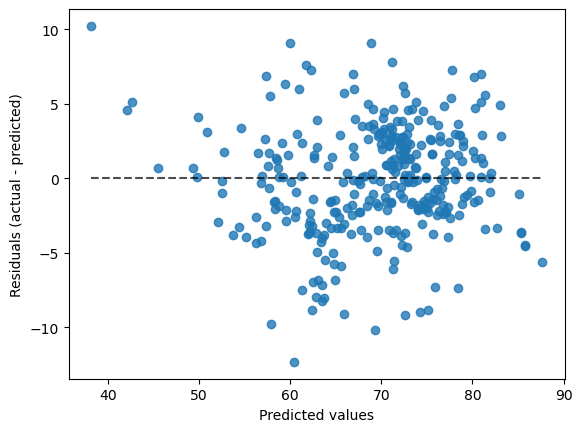

In [15]:
display = PredictionErrorDisplay.from_estimator(model2, X_test, y_test, kind="residual_vs_predicted")

## Task 5: Responses

In [16]:
df["HIV/AIDS"] = pd.to_numeric(df["HIV/AIDS"])
df["percentage expenditure"] = pd.to_numeric(df["percentage expenditure"])

df["Task_5"] = df["HIV/AIDS"] * df["percentage expenditure"]
Task_5_X = df[["Task_5"]]

### HIV/AIDS is a permanent disease that needs consistant treatment, so I would assume it plays a big impact on someones budget percantage.

In [17]:
model3 = LinearRegression()
model3.fit(Task_5_X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
predicted3 = model3.predict(Task_5_X)
R_squared3 = r2_score(y, predicted3)

print(f"R Square: {R_squared3:.2f}")

R Square: 0.06


In [20]:
Coef_Ranking3 = model3.coef_

Absolute_Coefficient3 = pd.DataFrame({
    'Column': Task_5_X.columns,
    'Absolute Coefficient Value': abs(Coef_Ranking3),
})
print(Absolute_Coefficient3)

   Column  Absolute Coefficient Value
0  Task_5                    0.001259


### Positive, it really has no significance as the absolute coefficient value is so small.